In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

OUTPUT_ROOT = Path("./mutation_sensitivity_outputs").resolve()

MAX_ROWS_PER_MODEL = 2_000_000
CONNECT_MEDIANS = True
SHOW_FLIERS = False

SAVE_FIGS = True
FIG_DIR = OUTPUT_ROOT / "plots"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Using output folder:", OUTPUT_ROOT)

Using output folder: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs


In [2]:
model_dirs = sorted([d for d in OUTPUT_ROOT.iterdir() if d.is_dir()])
model_names = [d.name for d in model_dirs]

records = []
for model_dir in model_dirs:
    for pq in sorted(model_dir.glob("*.parquet")):
        records.append({"model": model_dir.name, "file": str(pq)})

manifest_df = pd.DataFrame(records)

print("Models found:", model_names)
print("Total parquet files:", len(manifest_df))
display(manifest_df.groupby("model").size().rename("parquet_count").reset_index())

if len(manifest_df) > 0:
    sample = pd.read_parquet(manifest_df.iloc[0]["file"])
    print("Sample columns:")
    print(sample.columns.tolist())
    display(sample.head(3))

Models found: ['DNABERT-2', 'DNABERT-S', 'GPN', 'GROVER', 'GenaLM', 'Hyena-160k', 'Hyena-16k', 'Hyena-1k', 'Hyena-1m', 'Hyena-32k', 'Hyena-450k', 'NT2.5B-1K', 'NT2.5B-MS', 'NT500M', 'PhyloGPN', 'plots']
Total parquet files: 1120


,model,parquet_count
0,DNABERT-2,80
1,DNABERT-S,80
2,GPN,80
3,GROVER,80
4,GenaLM,80
5,Hyena-160k,80
6,Hyena-16k,80
7,Hyena-1k,80
8,Hyena-1m,80
9,Hyena-32k,80


Sample columns:
['model', 'global_sequence_index', 'label', 'sequence_type', 'mutation_percent', 'mutation_instance', 'distance', 'cosine_similarity', 'mutated_sequence', 'mutated_embedding', 'original_embedding']


,model,global_sequence_index,label,sequence_type,mutation_percent,mutation_instance,distance,cosine_similarity,mutated_sequence,mutated_embedding,original_embedding
0,DNABERT-2,37500,0,coding,5,0,4.274433,0.200033,TGGCTGACCTCGATTTAAAGAGACAGCAACTGTCGTGGTCCTGGAA...,"[-0.0412846, -0.18434782, -0.17205137, -0.0522...","[0.050299145, -0.010250635, -0.13859227, -0.15..."
1,DNABERT-2,37500,0,coding,5,1,3.072694,0.533001,TCGCTGGCCTCGATTTAAAGAGACAGAAGCTGTCGGGGTAATGGAA...,"[0.089394964, -0.18095279, -0.2784935, -0.0442...","[0.050299145, -0.010250635, -0.13859227, -0.15..."
2,DNABERT-2,37500,0,coding,5,2,1.033259,0.945611,TGGCTGGCCTCTATTTACAGAGACAGAAGCTGTCGGGGTCCTGGAA...,"[0.044003453, 0.03021047, -0.20713836, -0.1059...","[0.050299145, -0.010250635, -0.13859227, -0.15..."


In [3]:
def _safe_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", text)


def _plot_one_metric_panel(ax, model_df, metric_col, y_label, title_suffix, y_limits=None):
    pct_order = sorted(model_df["mutation_percent"].unique().tolist())
    pct_labels = [str(p) for p in pct_order]

    model_df = model_df.copy()
    model_df["mutation_percent_str"] = model_df["mutation_percent"].astype(str)
    model_df["mutation_percent_str"] = pd.Categorical(
        model_df["mutation_percent_str"],
        categories=pct_labels,
        ordered=True,
    )

    box_palette = {"coding": "#8fb9ff", "non-coding": "#ffb38a"}
    line_palettes = {
        "distance": {"coding": "#0b4fce", "non-coding": "#c2410c"},
        "cosine_similarity": {"coding": "#0f766e", "non-coding": "#b91c1c"},
    }

    sns.boxplot(
        data=model_df,
        x="mutation_percent_str",
        y=metric_col,
        hue="sequence_type",
        order=pct_labels,
        showfliers=SHOW_FLIERS,
        palette=box_palette,
        ax=ax,
    )

    if CONNECT_MEDIANS:
        med_df = (
            model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
            .median()
        )
        sns.lineplot(
            data=med_df,
            x="mutation_percent_str",
            y=metric_col,
            hue="sequence_type",
            estimator=None,
            markers=True,
            dashes=False,
            linewidth=2.2,
            sort=False,
            legend=False,
            palette=line_palettes.get(metric_col),
            ax=ax,
        )

    ax.set_title(title_suffix)
    ax.set_xlabel("Mutation Percentage")
    ax.set_ylabel(y_label)

    if y_limits is not None:
        ax.set_ylim(*y_limits)

    # Deduplicate legend entries (box + line can repeat)
    handles, labels = ax.get_legend_handles_labels()
    dedup = {}
    for h, l in zip(handles, labels):
        if l not in dedup:
            dedup[l] = h
    ax.legend(dedup.values(), dedup.keys(), title="Sequence Type")


def plot_side_by_side_for_model(model_name):
    model_files = sorted((OUTPUT_ROOT / model_name).glob("*.parquet"))
    if len(model_files) == 0:
        print(f"[{model_name}] no parquet files found.")
        return

    needed_cols = ["mutation_percent", "sequence_type", "distance", "cosine_similarity"]
    frames = []

    for f in model_files:
        try:
            df = pd.read_parquet(f, columns=needed_cols)
            frames.append(df)
        except Exception as e:
            print(f"[{model_name}] skipped file {f.name}: {e}")

    if len(frames) == 0:
        print(f"[{model_name}] no readable rows.")
        return

    model_df = pd.concat(frames, ignore_index=True)
    model_df = model_df.dropna(
        subset=["mutation_percent", "sequence_type", "distance", "cosine_similarity"]
    ).copy()

    if len(model_df) > MAX_ROWS_PER_MODEL:
        model_df = model_df.sample(MAX_ROWS_PER_MODEL, random_state=42)
        print(f"[{model_name}] downsampled to {len(model_df)} rows")

    model_df["mutation_percent"] = model_df["mutation_percent"].astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharex=False)

    _plot_one_metric_panel(
        ax=axes[0],
        model_df=model_df,
        metric_col="distance",
        y_label="Euclidean Distance to Original Embedding",
        title_suffix="Euclidean Distance",
        y_limits=None,
    )

    _plot_one_metric_panel(
        ax=axes[1],
        model_df=model_df,
        metric_col="cosine_similarity",
        y_label="Cosine Similarity to Original Embedding",
        title_suffix="Cosine Similarity",
        y_limits=(-1.0, 1.0),
    )

    fig.suptitle(f"{model_name} | Mutation Sensitivity", fontsize=14, y=1.02)
    plt.tight_layout()

    if SAVE_FIGS:
        out_name = f"{_safe_name(model_name)}_distance_cosine_side_by_side.png"
        out_path = FIG_DIR / out_name
        plt.savefig(out_path, dpi=180, bbox_inches="tight")
        print("Saved:", out_path)

    plt.show()

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/DNABERT-2_distance_cosine_side_by_side.png


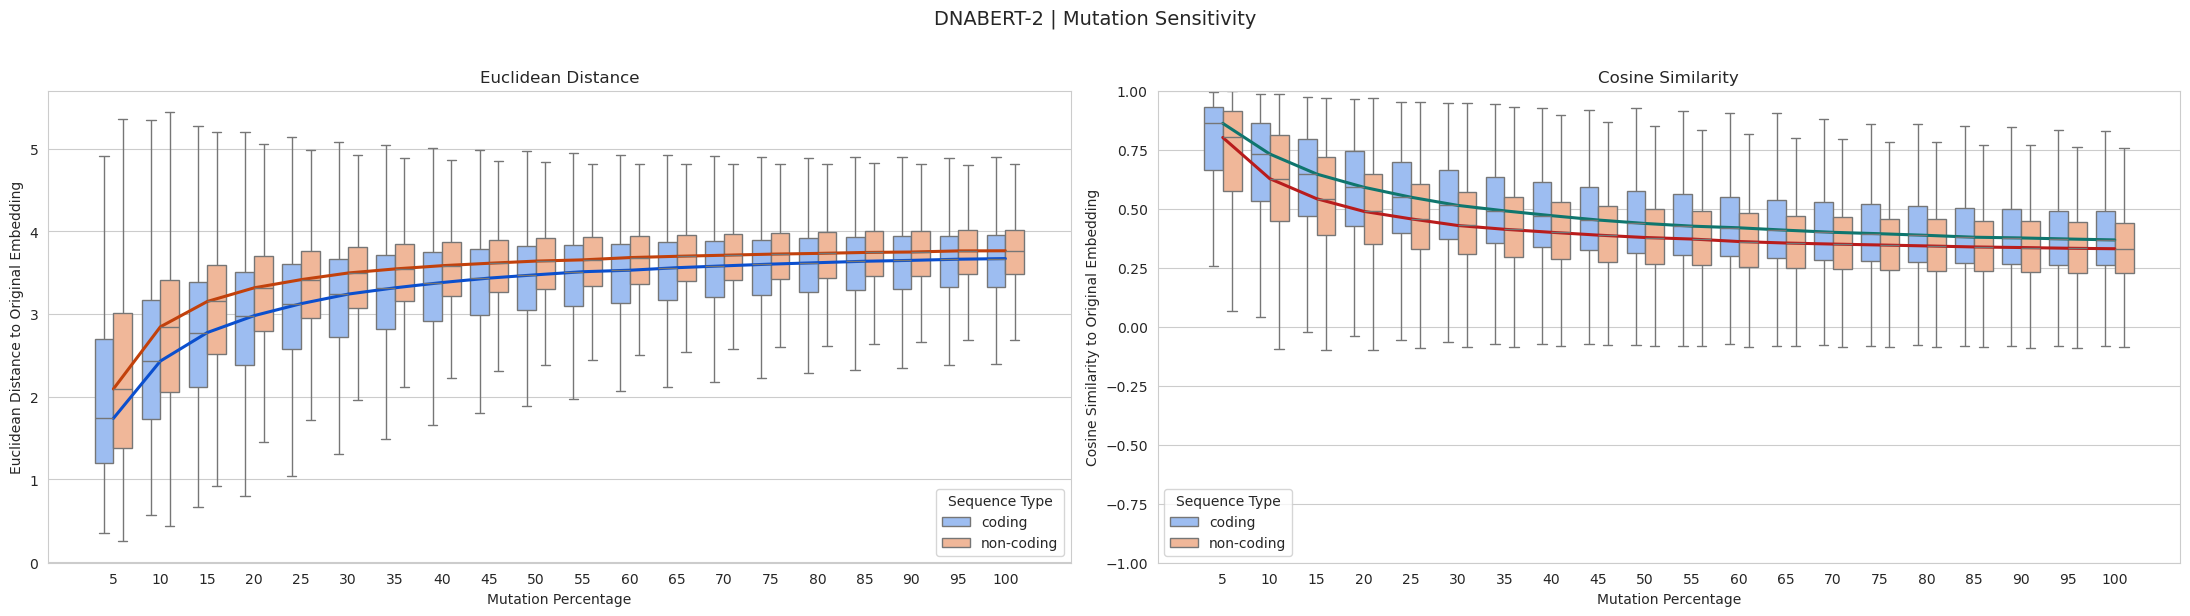

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/DNABERT-S_distance_cosine_side_by_side.png


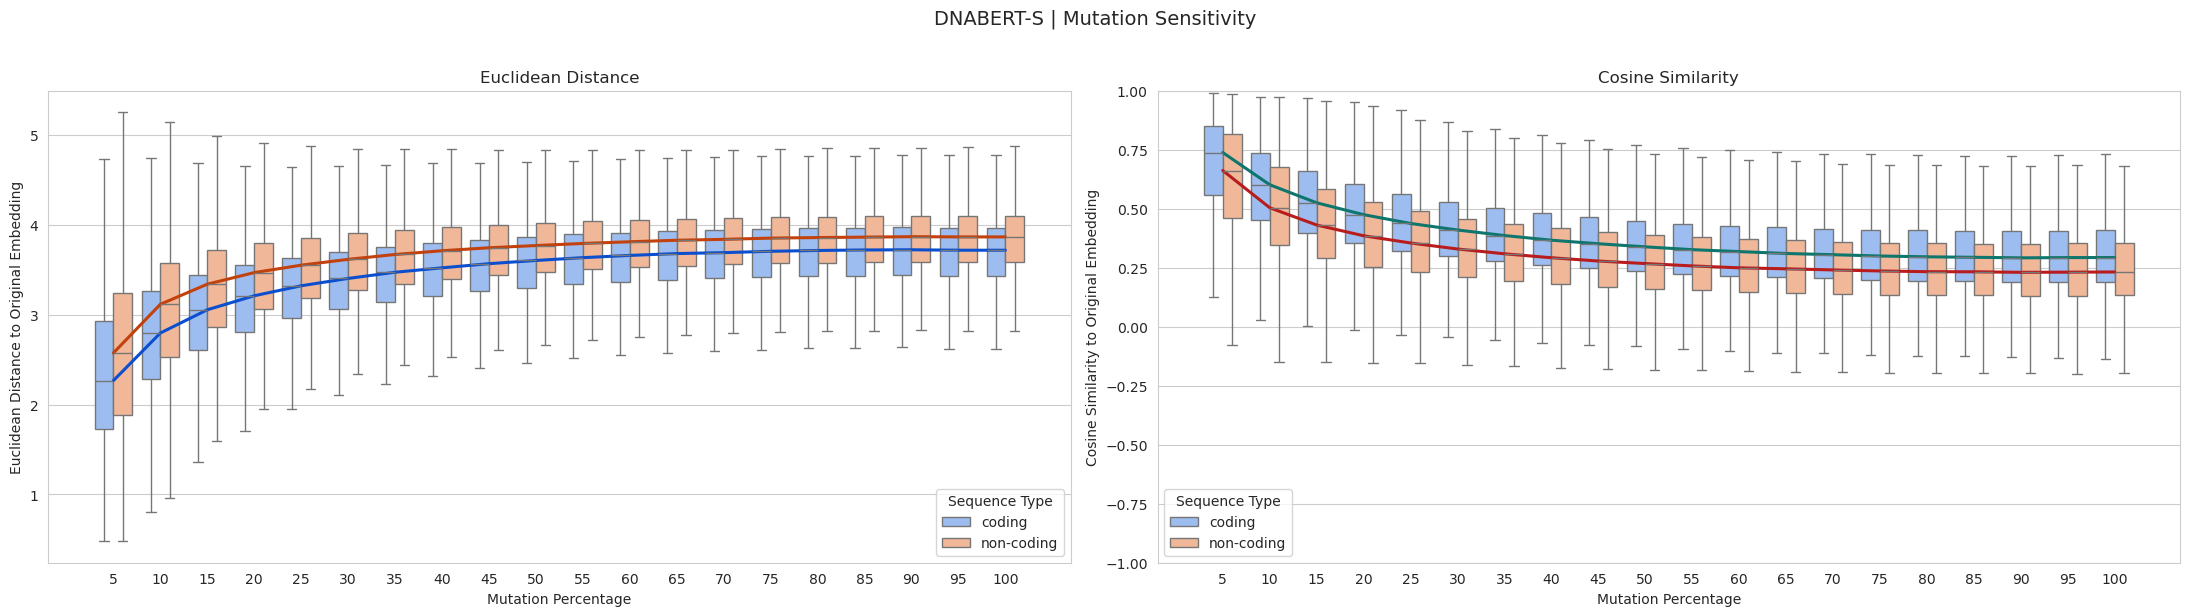

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/GPN_distance_cosine_side_by_side.png


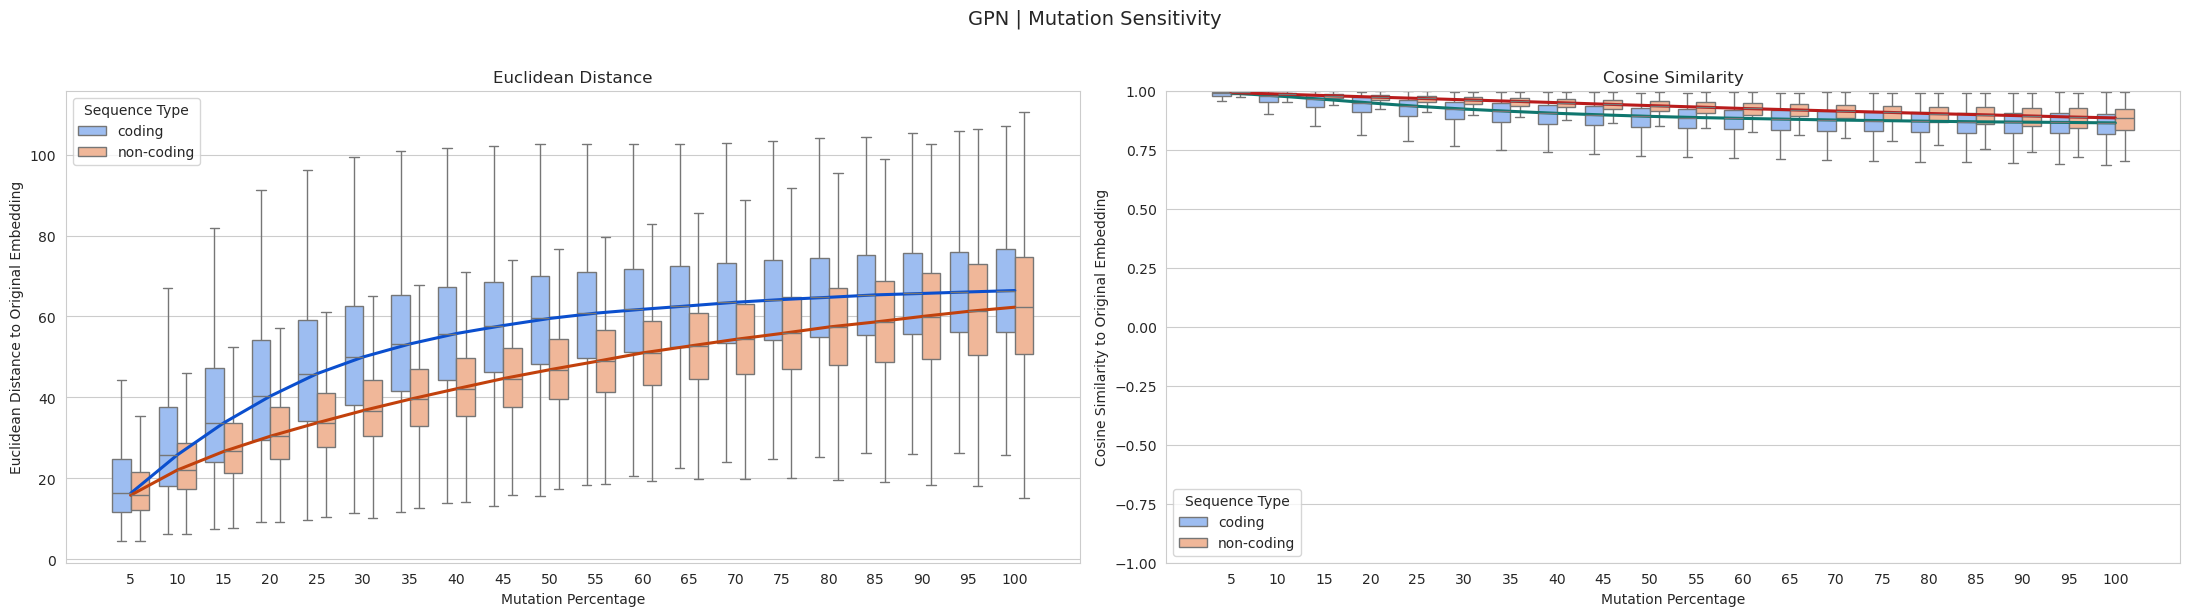

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/GROVER_distance_cosine_side_by_side.png


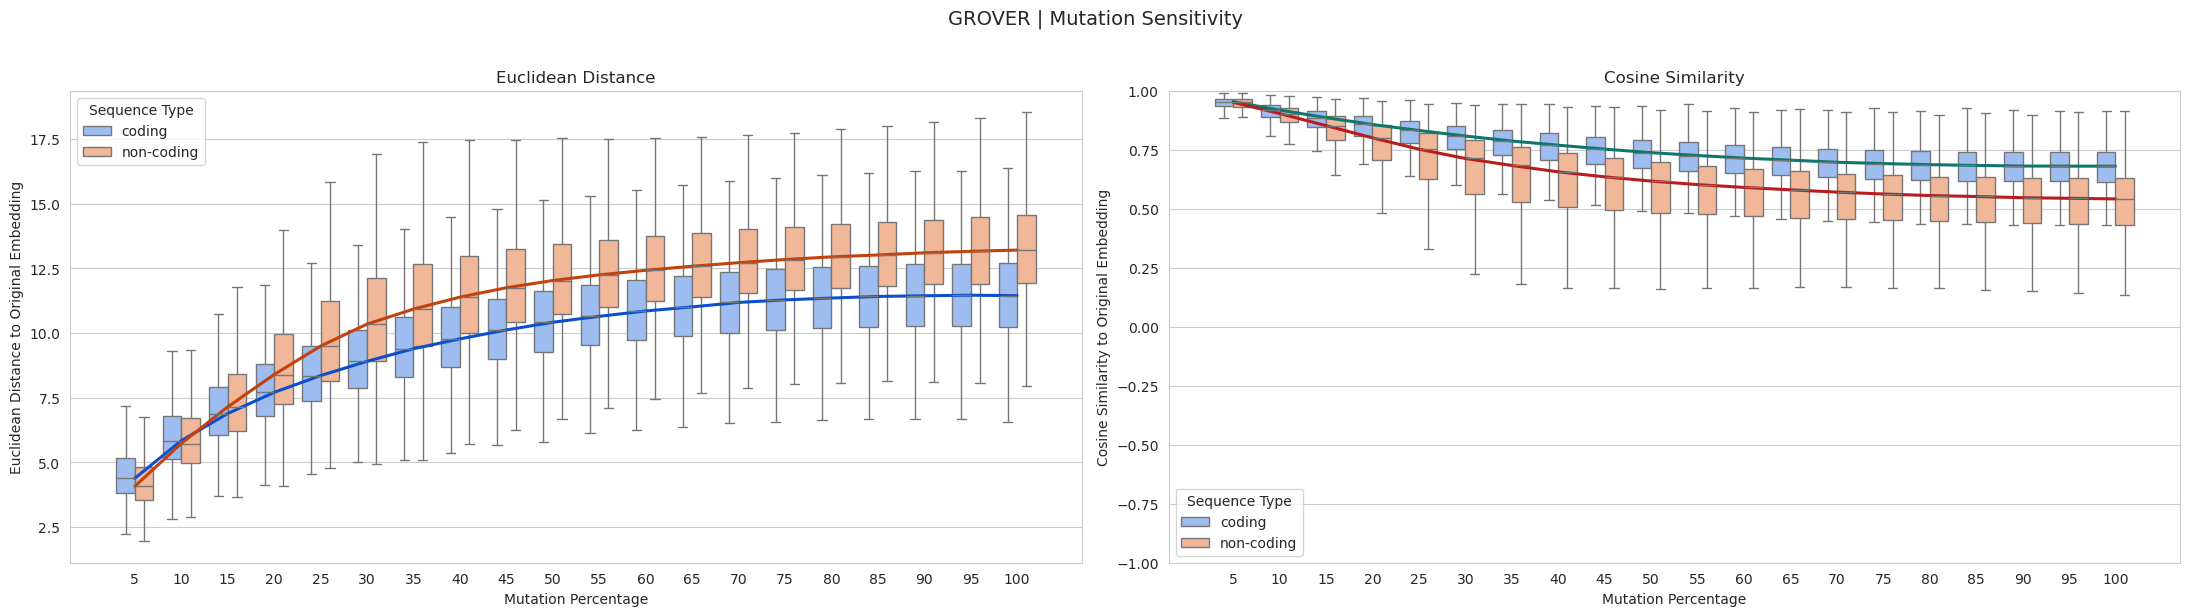

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/GenaLM_distance_cosine_side_by_side.png


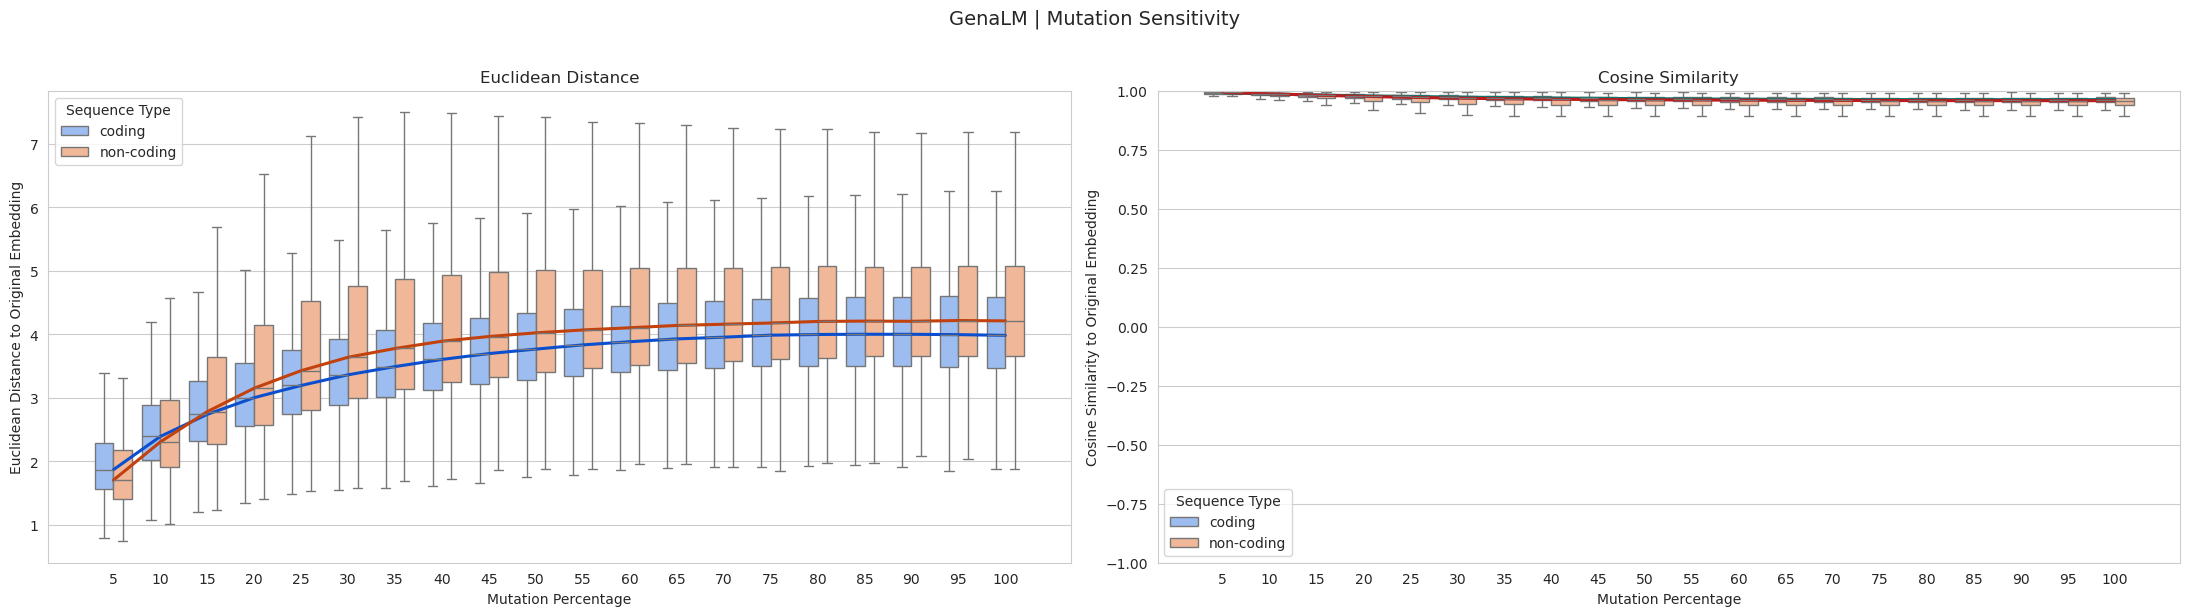

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/Hyena-160k_distance_cosine_side_by_side.png


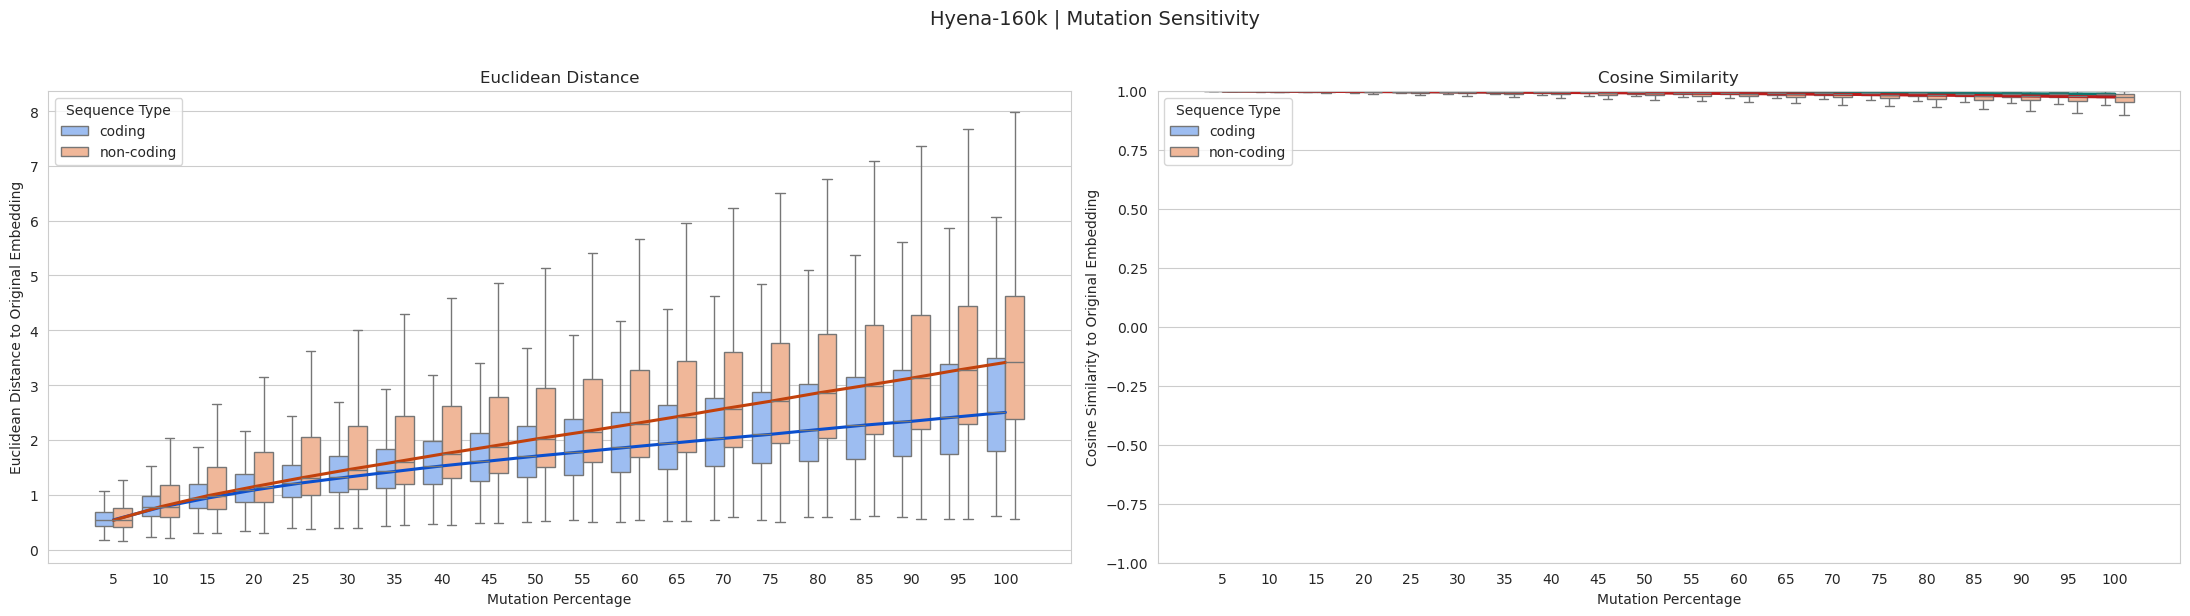

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/Hyena-16k_distance_cosine_side_by_side.png


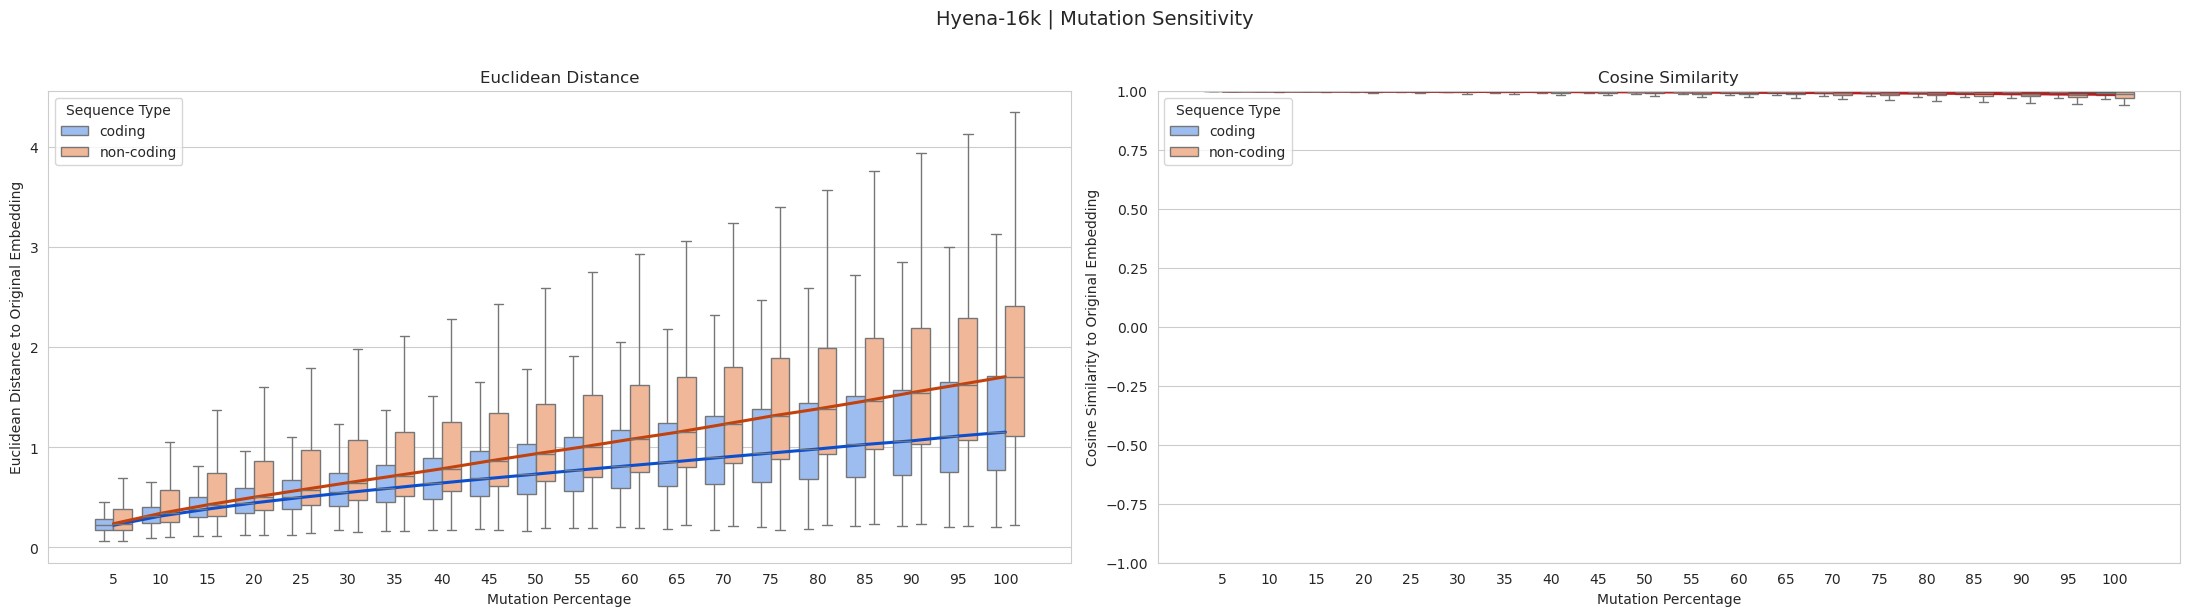

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/Hyena-1k_distance_cosine_side_by_side.png


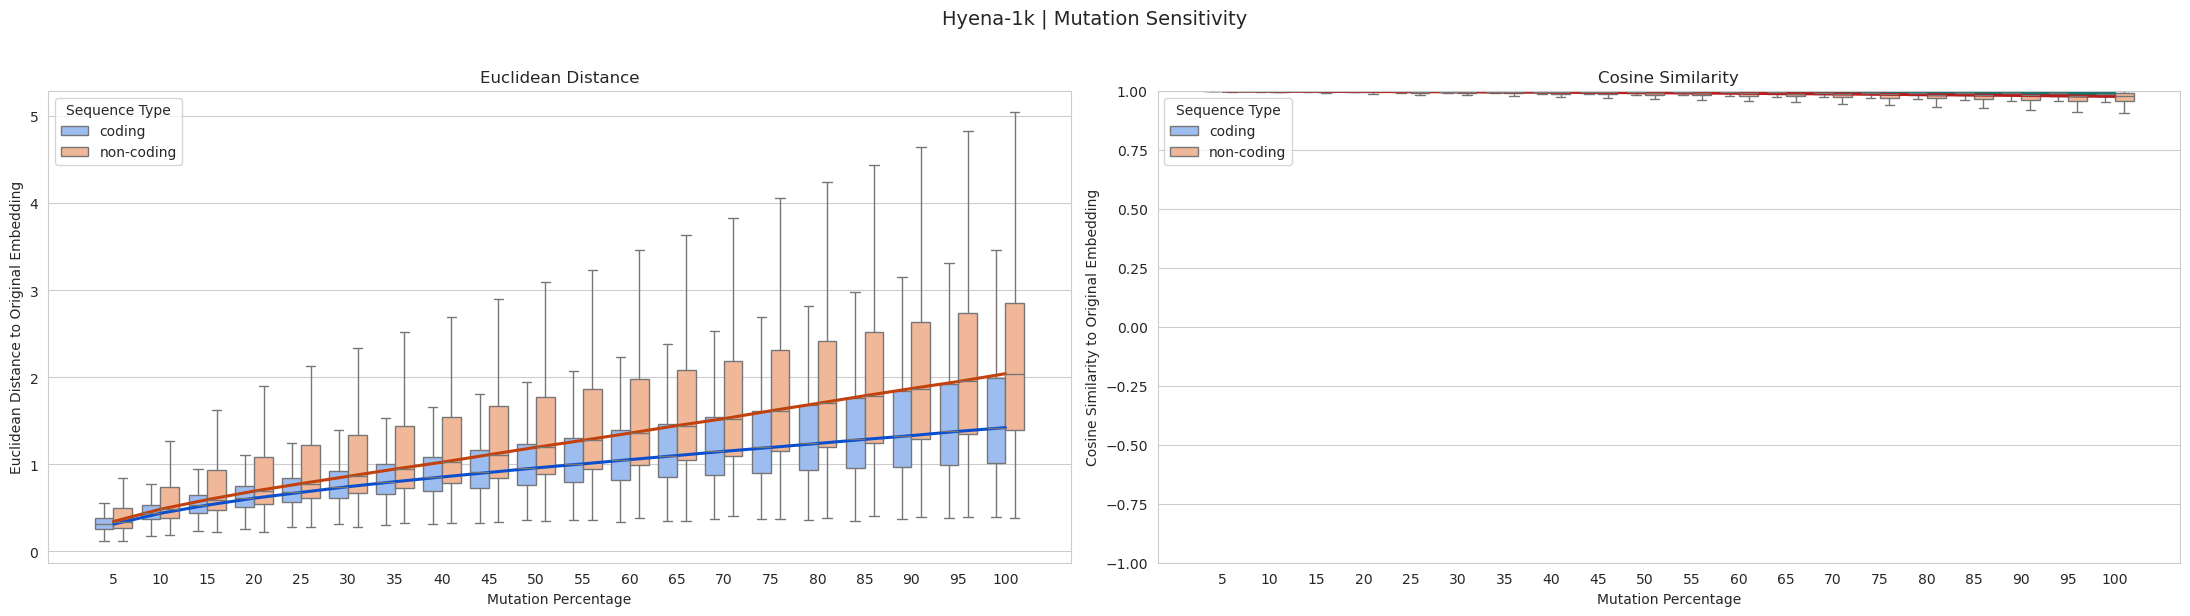

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/Hyena-1m_distance_cosine_side_by_side.png


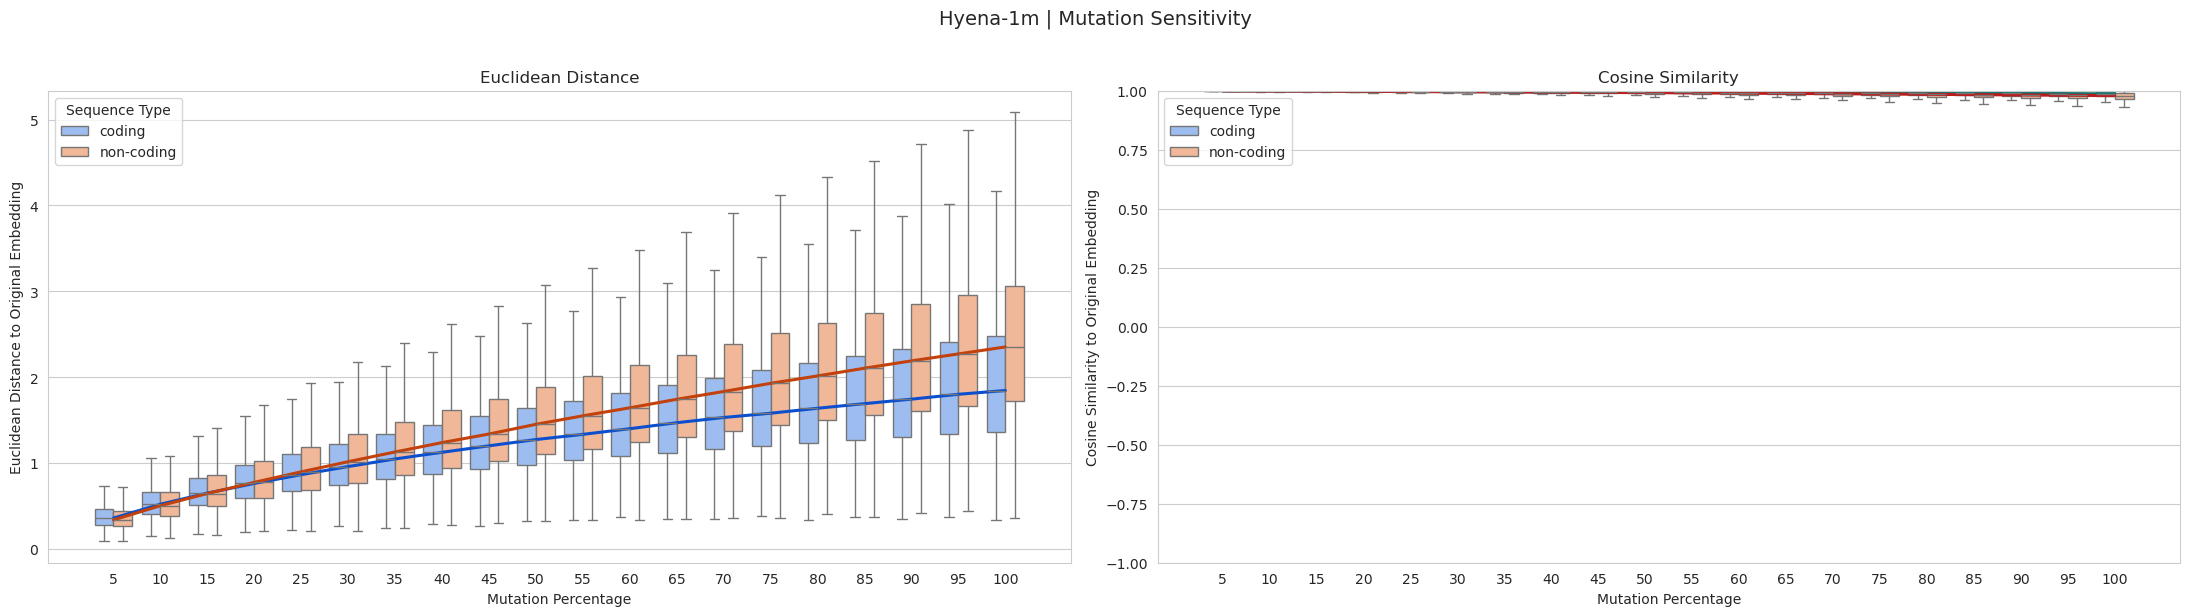

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/Hyena-32k_distance_cosine_side_by_side.png


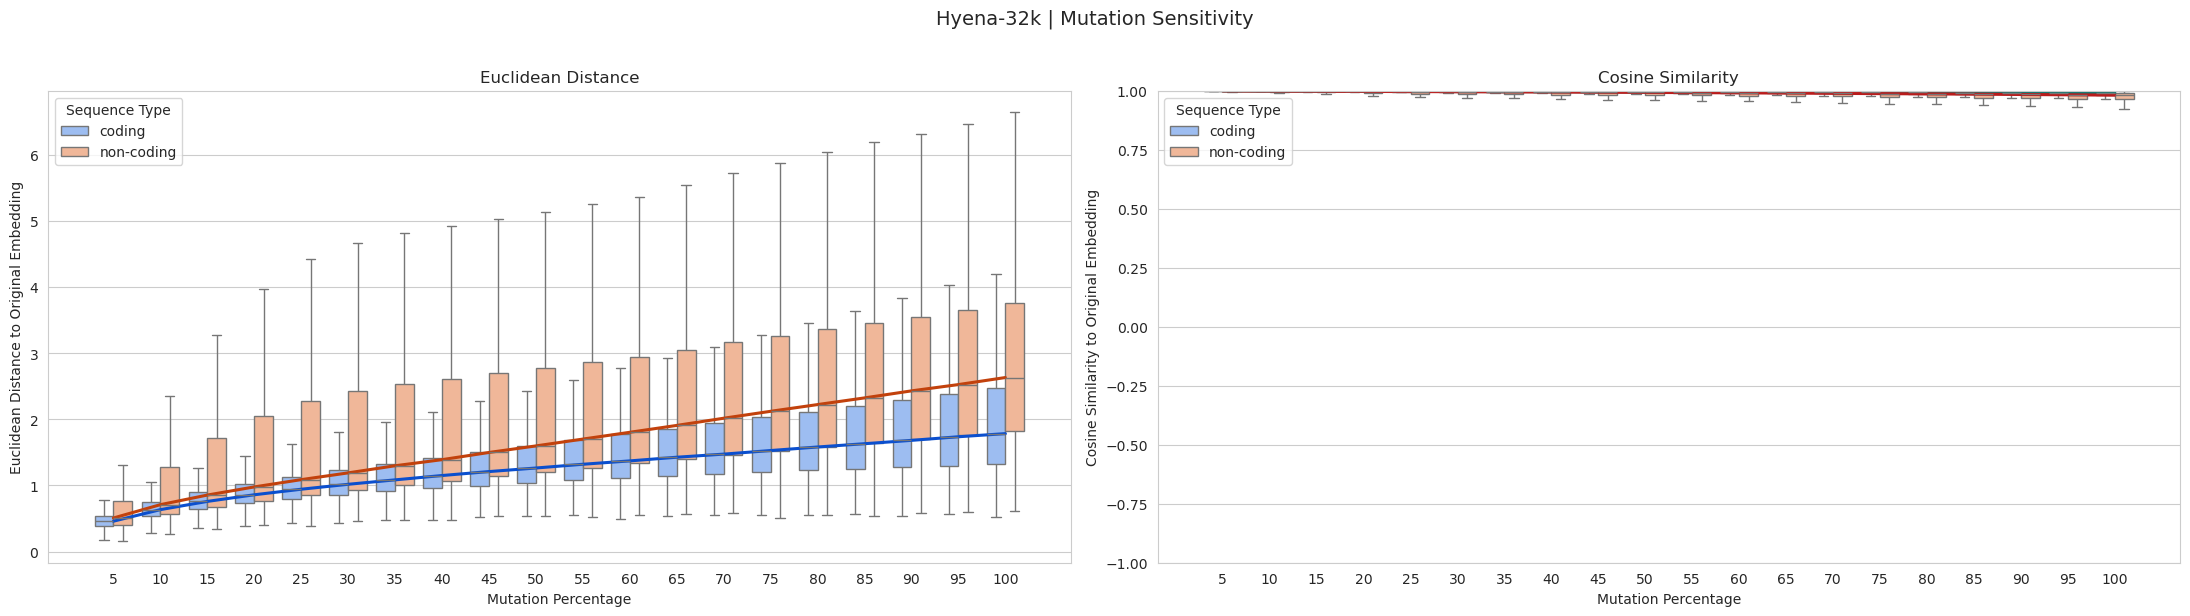

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/Hyena-450k_distance_cosine_side_by_side.png


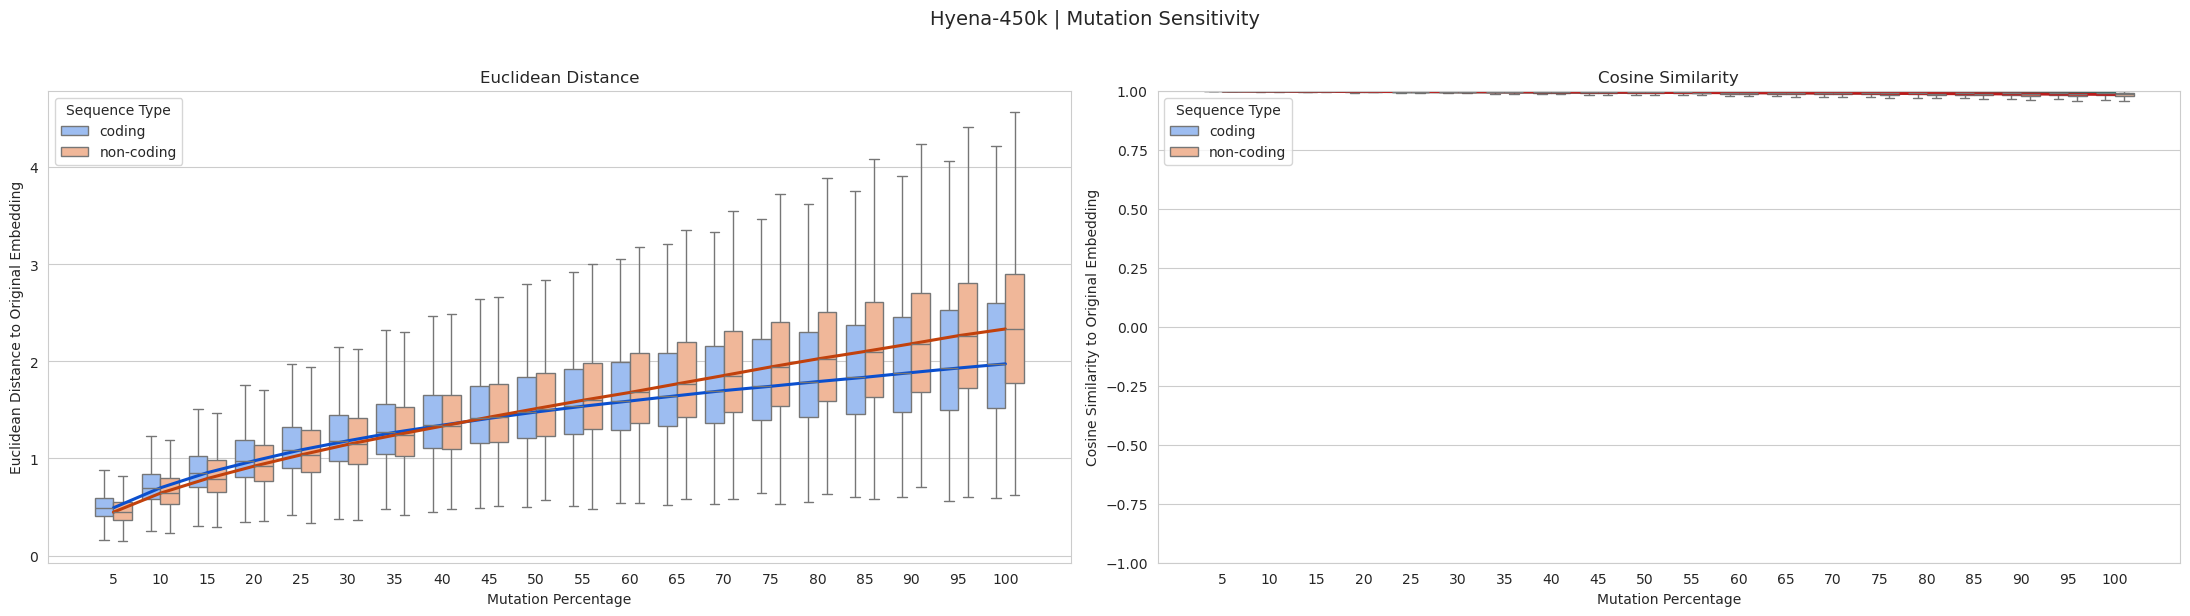

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/NT2.5B-1K_distance_cosine_side_by_side.png


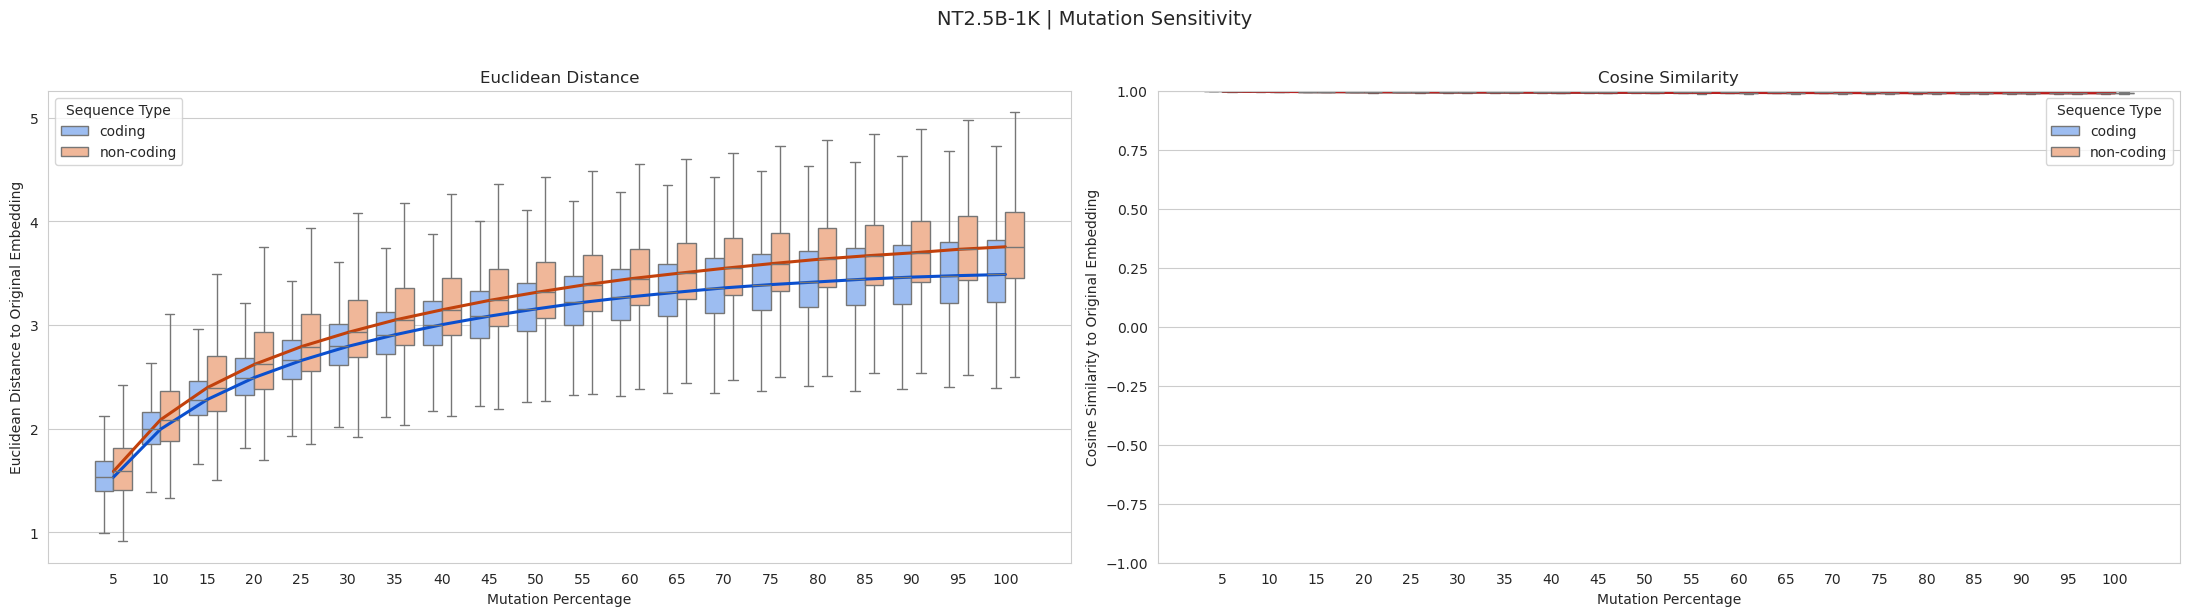

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/NT2.5B-MS_distance_cosine_side_by_side.png


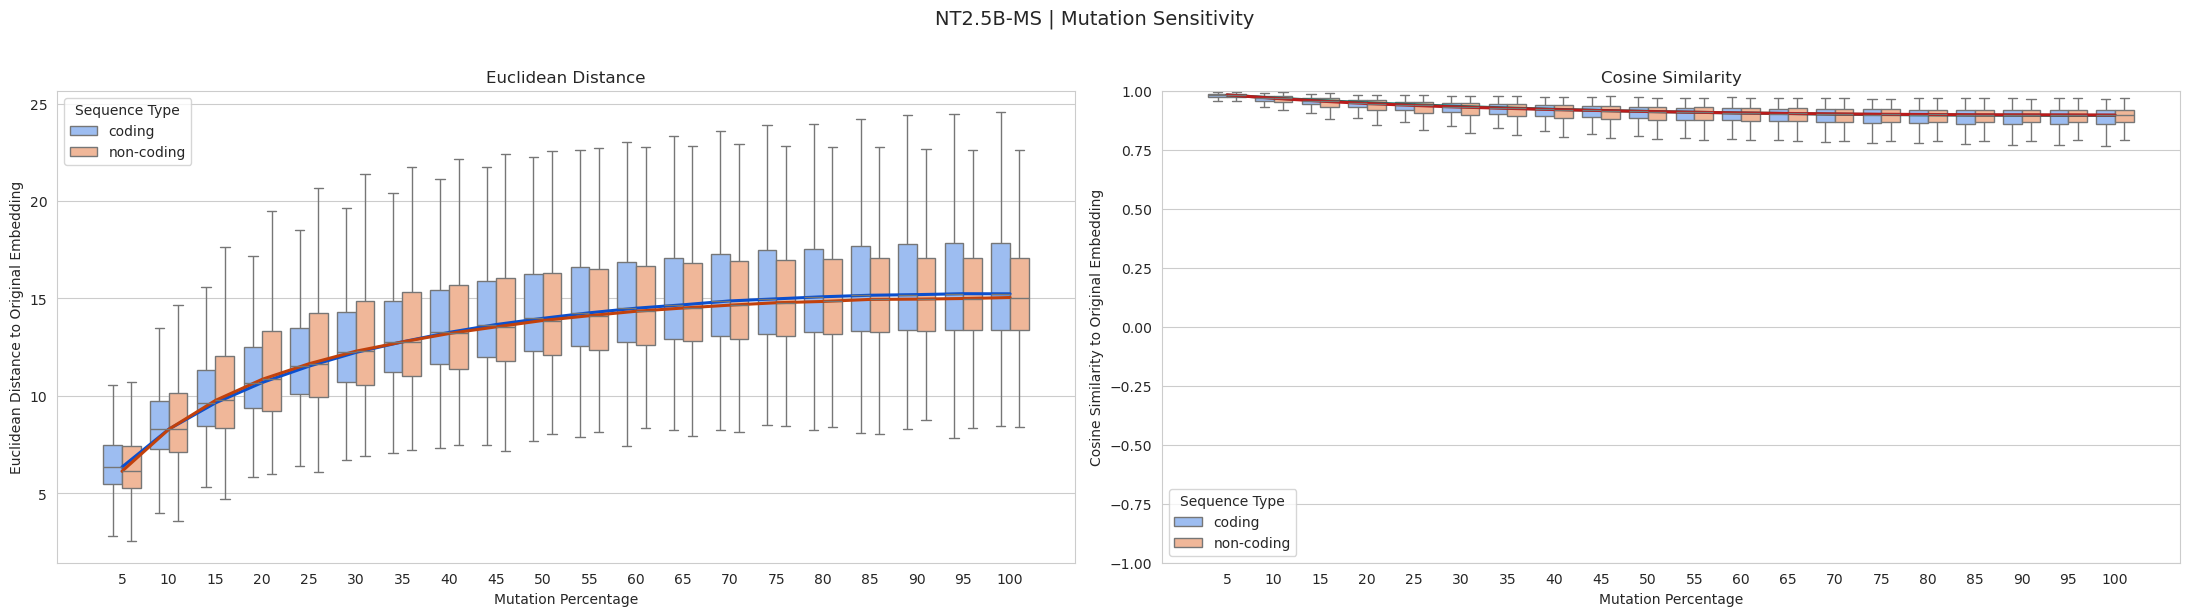

/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]
/tmp/ipykernel_2586177/3710907952.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)[metric_col]


Saved: /storage/bt20d204/ruhaib/Model Evaluation/Mutation Sensitivity/GB sequences/mutation_sensitivity_outputs/plots/NT500M_distance_cosine_side_by_side.png


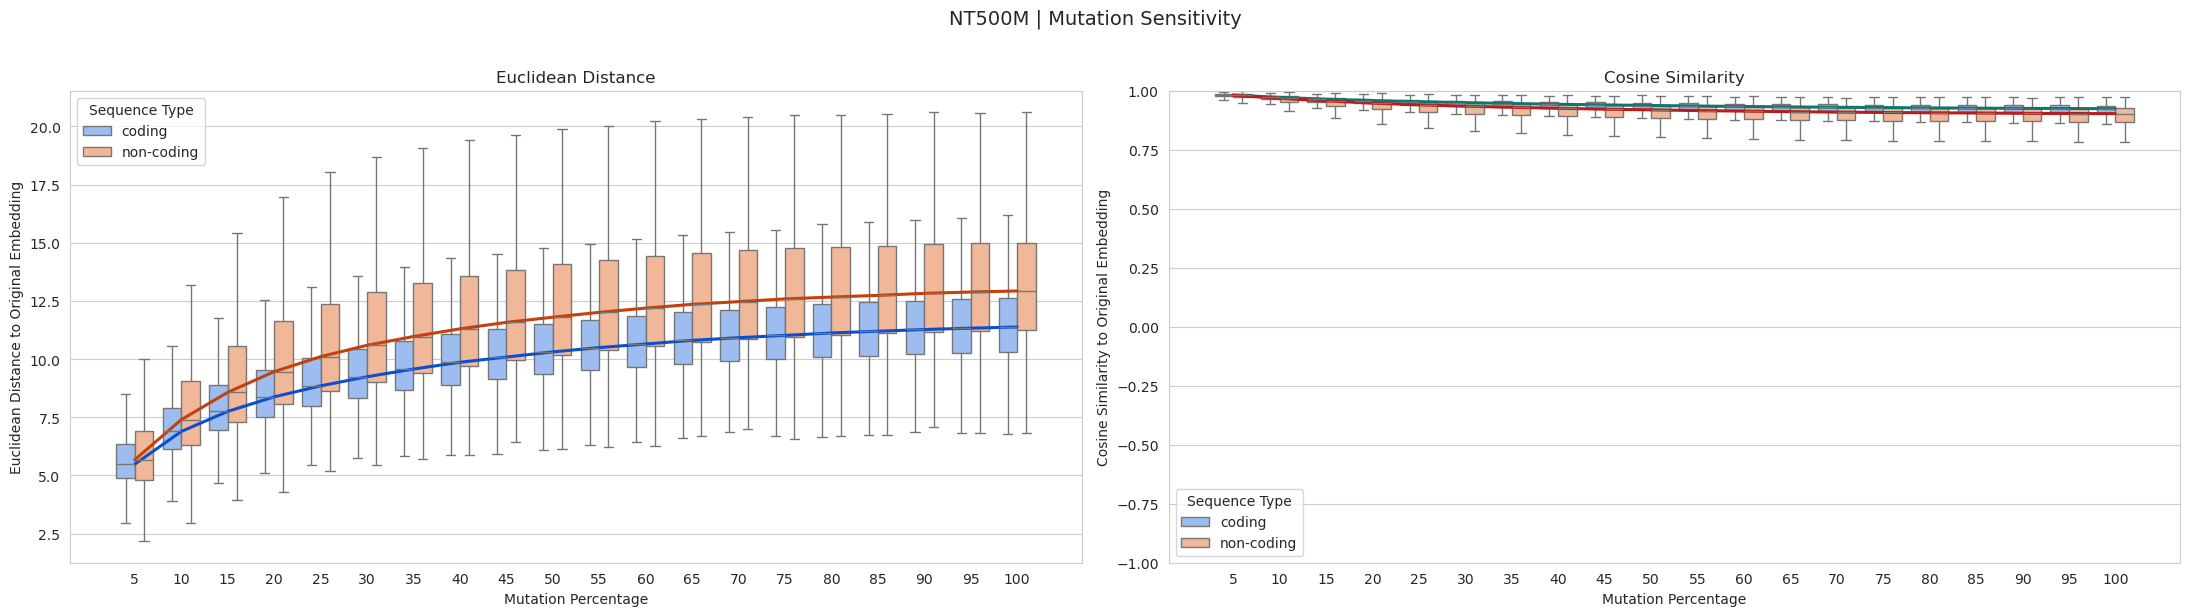

[PhyloGPN] no parquet files found.
[plots] no parquet files found.


In [4]:
for model_name in model_names:
    plot_side_by_side_for_model(model_name)